# DPWH Exploratory Data Analysis
## Philippine Infrastructure Projects (2019-2025)

---

### Research Objectives

1. **Geographic Center of Gravity Migration** - How has total award amounts migrated across the Philippines between 2019 and 2025?
2. **Investment Density** - Which regions show highest investment per km² for specific categories?
3. **Budget-to-Award Gap** - Does the gap between approved budget (ABC) and award amount vary over time?
4. **Year-over-Year Category Growth** - Which categories saw largest YoY increases?
5. **Category Cluster Trends** - What are the trends for project category clusters over regions?
6. **Temporal Bias** - Which locations have temporal bias for awarding high-amount contracts in specific quarters?

---
### Dataset Overview
- **Source**: dpwh_transparency_data_all_details.parquet
- **Records**: 248,421 infrastructure projects
- **Columns**: 52 attributes
- **Coverage**: Philippines (18 regions, 220 provinces)

In [1]:
# =============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

In [2]:
# =============================================================================
# CELL 2: LOAD DATA & INITIAL OVERVIEW
# =============================================================================
# REASONING: Load the parquet file - it's compressed and loads quickly
df = pd.read_parquet('dpwh_transparency_data_all_details.parquet')

print(f"Original Dataset Shape: {df.shape}")
print(f"Records: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn List:\n{df.columns.tolist()}")

Original Dataset Shape: (248421, 52)
Records: 248,421
Columns: 52

Column List:
['contractId', 'description', 'category', 'status', 'budget', 'amountPaid', 'progress', 'region', 'province', 'infraType', 'latitude', 'longitude', 'verified', 'infraType_1', 'contractor', 'startDate', 'completionDate', 'infraYear', 'contractEffectivityDate', 'expiryDate', 'nysReason', 'programName', 'sourceOfFunds', 'isVerifiedByDpwh', 'isVerifiedByPublic', 'isLive', 'livestreamUrl', 'livestreamVideoId', 'livestreamDetectedAt', 'components', 'winnerNames', 'bidders', 'contractName', 'abc', 'status_1', 'fundingInstrument', 'advertisementDate', 'bidSubmissionDeadline', 'dateOfAward', 'awardAmount', 'advertisement', 'contractAgreement', 'noticeOfAward', 'noticeToProceed', 'programOfWork', 'engineeringDesign', 'latitude_1', 'longitude_1', 'coordinates', 'totalImages', 'latestImageDate', 'hasImages']


In [3]:
# =============================================================================
# CELL 3: DATA CLEANING - STEP 1: DROP NON-VIABLE COLUMNS
# =============================================================================
# REASONING: These 7 columns provide ZERO analytical value:
# - nysReason: 100% null (empty)
# - isVerifiedByDpwh, isVerifiedByPublic, isLive: 100% constant (same value for all rows)
# - livestreamUrl, livestreamVideoId, livestreamDetectedAt: 99.9% null (only 184 values exist)
# Including them would bloat memory and provide no insights.

non_viable_cols = [
    'nysReason',
    'isVerifiedByDpwh',
    'isVerifiedByPublic',
    'isLive',
    'livestreamUrl',
    'livestreamVideoId',
    'livestreamDetectedAt'
]

df = df.drop(columns=non_viable_cols, errors='ignore')
print(f"After dropping non-viable columns: {df.shape}")
print(f"Dropped: {len(non_viable_cols)} columns")

After dropping non-viable columns: (248421, 45)
Dropped: 7 columns


In [4]:
# =============================================================================
# CELL 4: DATA CLEANING - STEP 2: DROP DUPLICATE COLUMNS
# =============================================================================
# REASONING: These 4 columns are EXACT DUPLICATES of existing columns (likely from data merge):
# - infraType_1 duplicates infraType
# - status_1 duplicates status
# - latitude_1 duplicates latitude
# - longitude_1 duplicates longitude
# Keeping them would cause multicollinearity in any statistical analysis.
# They also inflate memory usage unnecessarily.

duplicate_cols = [
    'infraType_1',
    'status_1',
    'latitude_1',
    'longitude_1'
]

df = df.drop(columns=duplicate_cols, errors='ignore')
print(f"After dropping duplicate columns: {df.shape}")
print(f"Dropped: {len(duplicate_cols)} columns")

After dropping duplicate columns: (248421, 41)
Dropped: 4 columns


In [5]:
# =============================================================================
# CELL 5: DATA CLEANING - STEP 3: DROP LOW-VIABILITY COLUMNS
# =============================================================================
# REASONING: These 2 columns have HIGH MISSING RATES making them unreliable:
# - dateOfAward: 28% missing (too high for reliable temporal analysis)
# - latestImageDate: 45% missing (nearly half missing)
# For a cleaner analysis, we exclude these. They can be used later for conditional analysis if needed.

low_viability_cols = [
    'dateOfAward',
    'latestImageDate'
]

df = df.drop(columns=low_viability_cols, errors='ignore')
print(f"After dropping low-viability columns: {df.shape}")
print(f"Dropped: {len(low_viability_cols)} columns")

After dropping low-viability columns: (248421, 39)
Dropped: 2 columns


In [6]:
# =============================================================================
# CELL 6: DATA CLEANING - STEP 4: ANALYZE DATA COMPLETENESS BY YEAR
# =============================================================================
# REASONING: The dataset spans ~11 years. Not all years have equal data quality.
# We must check each year's completeness to ensure statistical validity.
# Decision rule: Keep years with >80% data completeness in core columns.
# This prevents year-level biases from low-quality data.

print("=" * 60)
print("DATA COMPLETENESS BY YEAR (infraYear)")
print("=" * 60)

core_cols = ['budget', 'region', 'startDate', 'latitude', 'longitude']
completeness = df.groupby('infraYear')[core_cols].apply(lambda x: x.notna().mean() * 100)
completeness['record_count'] = df.groupby('infraYear').size()
completeness['completeness_pct'] = completeness[core_cols].mean(axis=1)

print(completeness.round(1).to_string())

# Identify years with high completeness (>80%)
valid_years = completeness[completeness['completeness_pct'] >= 80].index.tolist()
print(f"\n✓ Years with >80% data completeness: {valid_years}")

DATA COMPLETENESS BY YEAR (infraYear)
           budget  region  startDate  latitude  longitude  record_count  completeness_pct
infraYear                                                                                
2016        100.0   100.0      100.0      43.1       43.1         21273              77.2
2017        100.0   100.0      100.0      49.6       49.6         26329              79.8
2018        100.0   100.0      100.0      99.8       99.8         26621              99.9
2019        100.0   100.0      100.0     100.0      100.0         22922             100.0
2020        100.0   100.0      100.0     100.0      100.0         21864             100.0
2021        100.0   100.0      100.0     100.0      100.0         23175             100.0
2022        100.0   100.0      100.0      99.9       99.9         23152             100.0
2023        100.0   100.0       99.9      99.1       99.1         25997              99.6
2024        100.0   100.0       92.2      91.7       91.7     

In [7]:
# =============================================================================
# CELL 7: DATA CLEANING - STEP 5: FILTER TO VALID YEARS
# =============================================================================
# REASONING: Based on the completeness analysis above, we keep only years with
# sufficient data quality (>80% complete). This ensures statistical validity
# for year-over-year comparisons and trend analysis.

years_to_keep = [y for y in valid_years if y is not None and str(y).isdigit()]
df = df[df['infraYear'].isin(years_to_keep)]
print(f"After filtering to valid years ({years_to_keep}): {df.shape}")
print(f"Records retained: {df.shape[0]:,}")

After filtering to valid years (['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']): (200456, 39)
Records retained: 200,456


In [8]:
# =============================================================================
# CELL 8: DATA CLEANING - STEP 6: CONVERT DATE COLUMNS TO DATETIME
# =============================================================================
# REASONING: Date columns are stored as strings - must convert to datetime for:
# - Temporal analysis (quarter extraction)
# - Year-over-year comparisons
# - Project duration calculations
# - Temporal bias analysis (Objective 6)

date_cols = ['startDate', 'completionDate', 'contractEffectivityDate', 
            'expiryDate', 'advertisementDate', 'bidSubmissionDeadline']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"✓ Converted {col}: {df[col].notna().sum():,} non-null dates")

print(f"\nDate columns converted to datetime format.")

✓ Converted startDate: 193,164 non-null dates
✓ Converted completionDate: 158,527 non-null dates
✓ Converted contractEffectivityDate: 193,542 non-null dates
✓ Converted expiryDate: 193,540 non-null dates
✓ Converted advertisementDate: 199,561 non-null dates
✓ Converted bidSubmissionDeadline: 199,561 non-null dates

Date columns converted to datetime format.


In [9]:
# =============================================================================
# CELL 9: DATA CLEANING - STEP 7: CLEAN NUMERIC STRING COLUMNS
# =============================================================================
# REASONING: The 'abc' (Approved Budget for Contract) and 'awardAmount' columns
# contain string formatting with currency symbols and commas.
# Must convert to float64 for arithmetic operations:
# - Budget gap calculation (abc - awardAmount)
# - Investment density (budget / area)
# - Statistical summary (mean, median, etc.)

def clean_currency(x):
    """Remove currency symbols and commas, convert to float."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    x = str(x).replace('₱', '').replace(',', '').strip()
    try:
        return float(x)
    except:
        return np.nan

if 'abc' in df.columns:
    df['abc'] = df['abc'].apply(clean_currency)
    print(f"✓ Cleaned 'abc': {df['abc'].notna().sum():,} non-null values")

if 'awardAmount' in df.columns:
    df['awardAmount'] = df['awardAmount'].apply(clean_currency)
    print(f"✓ Cleaned 'awardAmount': {df['awardAmount'].notna().sum():,} non-null values")

print(f"\nNumeric columns cleaned and converted to float64.")

✓ Cleaned 'abc': 200,371 non-null values
✓ Cleaned 'awardAmount': 195,321 non-null values

Numeric columns cleaned and converted to float64.


In [10]:
# =============================================================================
# CELL 10: DATA CLEANING - STEP 8: DROP ROWS WITH MISSING COORDINATES
# =============================================================================
# REASONING: 13.56% of rows have missing lat/lon coordinates.
# This is below our 20% threshold, so we can safely DROP these rows.
# Keeping them would:
# - Skew center-of-gravity calculations (Objective 1)
# - Make investment density inaccurate (Objective 2)
# - Complicate geographic visualizations
# Alternative: Impute from province centroids - but dropping is cleaner.

missing_geo_pct = df['latitude'].isna().mean() * 100
print(f"Missing coordinates: {missing_geo_pct:.2f}%")

if missing_geo_pct < 20:
    df = df.dropna(subset=['latitude', 'longitude'])
    print(f"✓ Dropped rows with missing coordinates")
else:
    print(f"⚠ Missing >20%, would impute instead")

print(f"\nFinal cleaned dataset: {df.shape}")
print(f"Records retained: {df.shape[0]:,}")

Missing coordinates: 3.95%
✓ Dropped rows with missing coordinates

Final cleaned dataset: (192531, 39)
Records retained: 192,531


In [11]:
# =============================================================================
# CELL 11: FEATURE ENGINEERING
# =============================================================================
# REASONING: Create derived features needed for research objectives:
# 
# 1. region_area_km2 - Required for investment density (Obj 2)
# 2. budget_density - Investment per km² (directly measures Obj 2)
# 3. budget_gap - ABC vs award amount difference (Obj 3)
# 4. project_duration_days - Days to complete (shows efficiency)
# 5. fiscal_quarter - Q1-Q4 from date (needed for Obj 6 temporal bias)

# Philippine region areas (km²) - Official data
region_areas = {
    'National Capital Region': 636,
    'Cordillera Administrative Region': 19422,
    'Region I': 13349,
    'Region II': 26648,
    'Region III': 21080,
    'Region IV-A': 18230,
    'Region IV-B': 29073,
    'Region V': 18033,
    'Region VI': 20778,
    'Region VII': 10428,
    'Region VIII': 23744,
    'Region IX': 16821,
    'Region X': 17985,
    'Region XI': 20246,
    'Region XII': 22349,
    'Bangsamoro Autonomous Region in Muslim Mindanao': 34497,
    'Region XIII': 18318,
    'Negros Island Region': 15277,  # New region (2023)
}

df['region_area_km2'] = df['region'].map(region_areas)
print(f"✓ Created region_area_km2")

# Budget density (budget per km²)
df['budget_density'] = df['budget'] / df['region_area_km2']
print(f"✓ Created budget_density")

# Budget gap (abc - awardAmount)
df['budget_gap'] = df['abc'] - df['awardAmount']
df['budget_gap_pct'] = (df['budget_gap'] / df['abc']) * 100
print(f"✓ Created budget_gap and budget_gap_pct")

# Project duration (days)
df['project_duration_days'] = (df['completionDate'] - df['startDate']).dt.days
print(f"✓ Created project_duration_days")

# Fiscal quarter from advertisementDate
df['fiscal_quarter'] = df['advertisementDate'].dt.quarter
print(f"✓ Created fiscal_quarter")

print(f"\nFeature engineering complete.")

✓ Created region_area_km2
✓ Created budget_density
✓ Created budget_gap and budget_gap_pct
✓ Created project_duration_days
✓ Created fiscal_quarter

Feature engineering complete.


In [12]:
# =============================================================================
# CELL 12: DATASET SUMMARY AFTER CLEANING
# =============================================================================
print("=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Records: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nYears retained: {sorted(df['infraYear'].dropna().unique())}")
print(f"Regions: {df['region'].nunique()}")
print(f"Provinces: {df['province'].nunique()}")
print(f"InfraTypes: {df['infraType'].nunique()}")
print(f"\nBudget Statistics:")
print(f"  Min: ₱{df['budget'].min():,.0f}")
print(f"  Max: ₱{df['budget'].max():,.0f}")
print(f"  Mean: ₱{df['budget'].mean():,.0f}")
print(f"  Median: ₱{df['budget'].median():,.0f}")

CLEANED DATASET SUMMARY
Shape: (192531, 45)
Records: 192,531
Columns: 45

Years retained: ['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Regions: 18
Provinces: 220
InfraTypes: 6

Budget Statistics:
  Min: ₱0
  Max: ₱9,711,021,597
  Mean: ₱28,236,280
  Median: ₱9,897,420


---
## OBJECTIVE 1: Geographic Center of Gravity Migration

**Research Question:** How has the geographic "center of gravity" for total award amounts migrated across the Philippines between 2019 and 2025? Is the money staying in the same provinces or spreading out?

**Approach:**
- Calculate budget-weighted centroid (lat, lon) per year
- Plot trajectory on Philippines map
- Calculate annual dispersion (spread) to quantify concentration vs. dispersion

In [16]:
# =============================================================================
# CELL 13: OBJECTIVE 1 - DUAL ANALYSIS
# Part A: Regional Budget Distribution
# Part B: Geographic Center of Gravity (Lat/Lon)
# =============================================================================

# First, ensure infraYear is numeric and filter properly
df['infraYear'] = pd.to_numeric(df['infraYear'], errors='coerce')

# Filter to valid years (2019-2025 only)
df_filtered = df[df['infraYear'].between(2019, 2025)].copy()
df_filtered['infraYear'] = df_filtered['infraYear'].astype(int)

print(f"Years after filtering: {sorted(df_filtered['infraYear'].unique())}")

# =============================================================================
# PART A: REGIONAL BUDGET DISTRIBUTION ANALYSIS
# =============================================================================

# Calculate regional budget distribution by year
regional_budget = df_filtered.groupby(['infraYear', 'region'])['budget'].sum().reset_index()

# Calculate regional ranking
regional_ranking = regional_budget.sort_values(['infraYear', 'budget'], ascending=[True, False])
regional_ranking['rank'] = regional_ranking.groupby('infraYear')['budget'].rank(ascending=False, method='min')

# Calculate budget share percentage by region
regional_shares = df_filtered.groupby(['infraYear', 'region'])['budget'].sum()
regional_totals = regional_shares.groupby('infraYear').sum()
regional_shares_pct = (regional_shares / regional_totals * 100).reset_index()
regional_shares_pct.columns = ['infraYear', 'region', 'share_pct']

# Calculate HHI (Herfindahl Index - measures concentration)
hhi = regional_shares_pct.groupby('infraYear').apply(
    lambda x: ((x['share_pct'] / 100) ** 2).sum()
).reset_index()
hhi.columns = ['infraYear', 'hhi']

print("\n" + "="*60)
print("PART A: REGIONAL DISTRIBUTION")
print("="*60)
print(f"Top region each year:")
for year in sorted(regional_ranking['infraYear'].unique()):
    top_region = regional_ranking[regional_ranking['infraYear'] == year].iloc[0]
    print(f"  {year}: {top_region['region']} (₱{top_region['budget']/1e9:.1f}B)")

# =============================================================================
# PART B: GEOGRAPHIC CENTER OF GRAVITY (LAT/LON)
# =============================================================================

# Clean latitude and longitude
df_filtered['latitude'] = pd.to_numeric(df_filtered['latitude'], errors='coerce')
df_filtered['longitude'] = pd.to_numeric(df_filtered['longitude'], errors='coerce')

# Drop rows with missing coordinates for centroid calculation
df_centroid = df_filtered.dropna(subset=['latitude', 'longitude', 'budget'])

def weighted_centroid(group):
    """Calculate budget-weighted centroid (average lat/lon weighted by budget)"""
    weights = group['budget']
    total_weight = weights.sum()
    if total_weight <= 0 or total_weight is np.nan:
        return pd.Series({'center_lat': np.nan, 'center_lon': np.nan, 'total_budget': 0})
    center_lat = (group['latitude'] * weights).sum() / total_weight
    center_lon = (group['longitude'] * weights).sum() / total_weight
    return pd.Series({'center_lat': center_lat, 'center_lon': center_lon, 'total_budget': total_weight})

# Calculate centroids by year
centroids = df_centroid.groupby('infraYear').apply(weighted_centroid).reset_index()
centroids = centroids.sort_values('infraYear')
centroids = centroids.dropna(subset=['center_lat', 'center_lon'])

print("\n" + "="*60)
print("PART B: GEOGRAPHIC CENTER OF GRAVITY (LAT/LON)")
print("="*60)

# Define region centroid coordinates for mapping lat/lon to regions
# These are approximate centroids for each region
region_centroids = {
    'National Capital Region': (14.5995, 120.9842),
    'Cordillera Administrative Region': (17.0833, 120.7167),
    'Region I': (16.0833, 120.3667),
    'Region II': (16.9167, 121.7667),
    'Region III': (15.1333, 120.8333),
    'Region IV-A': (14.1667, 121.2167),
    'Region IV-B': (12.3333, 121.0833),
    'Region V': (13.4167, 123.4167),
    'Region VI': (10.6667, 122.9500),
    'Region VII': (10.3167, 123.8833),
    'Region VIII': (11.2500, 125.0000),
    'Region IX': (7.8333, 122.4167),
    'Region X': (8.3333, 124.5000),
    'Region XI': (7.1667, 125.6667),
    'Region XII': (6.5000, 124.8500),
    'Region XIII': (8.9500, 125.5333),
    'Bangsamoro Autonomous Region in Muslim Mindanao': (7.1667, 124.2167),
    'Negros Island Region': (10.2500, 123.0833),
}

def find_closest_region(lat, lon, region_centroids):
    """Find the region whose centroid is closest to the given point"""
    min_dist = float('inf')
    closest_region = None
    for region, (r_lat, r_lon) in region_centroids.items():
        dist = np.sqrt((r_lat - lat)**2 + (r_lon - lon)**2)
        if dist < min_dist:
            min_dist = dist
            closest_region = region
    return closest_region

# Add region assignment to each centroid
centroids['assigned_region'] = centroids.apply(
    lambda row: find_closest_region(row['center_lat'], row['center_lon'], region_centroids),
    axis=1
)

print("\nBudget-Weighted Center of Gravity by Year:")
print(centroids[['infraYear', 'center_lat', 'center_lon', 'assigned_region', 'total_budget']].to_string(index=False))

print(f"\nMigration Summary:")
first_region = centroids.iloc[0]['assigned_region']
last_region = centroids.iloc[-1]['assigned_region']
print(f"  Started in: {first_region}")
print(f"  Ended in: {last_region}")
print(f"  Direction: {'Northward' if centroids.iloc[-1]['center_lat'] > centroids.iloc[0]['center_lat'] else 'Southward'}")

Years after filtering: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

PART A: REGIONAL DISTRIBUTION
Top region each year:
  2019: Region III (₱40.4B)
  2020: Region XI (₱49.2B)
  2021: Region XI (₱52.7B)
  2022: Region IV-A (₱72.6B)
  2023: Region III (₱104.6B)
  2024: Region III (₱144.6B)
  2025: Region III (₱101.0B)

PART B: GEOGRAPHIC CENTER OF GRAVITY (LAT/LON)

Budget-Weighted Center of Gravity by Year:
 infraYear  center_lat  center_lon assigned_region  total_budget
      2019   12.219642  122.749519        Region V  4.114901e+11
      2020   11.952525  122.814370       Region VI  4.899226e+11
      2021   11.934477  122.909929       Region VI  4.798727e+11
      2022   12.290909  122.755911        Region V  7.292243e+11
      2023   12.485422  122.589826        Region V  8.844080e+11
      2024   12.553464  122.604117        Region V  1.045990e+12
      2025   12.633352  122.443330        Region V  7.580892e+11



Years after filtering: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Budget-Weighted Center of Gravity by Year:
 infraYear  center_lat  center_lon centroid_region
      2019   12.219642  122.749519        Region V
      2020   11.952525  122.814370       Region VI
      2021   11.934477  122.909929       Region VI
      2022   12.290909  122.755911        Region V
      2023   12.485422  122.589826        Region V
      2024   12.553464  122.604117        Region V
      2025   12.633352  122.443330        Region V


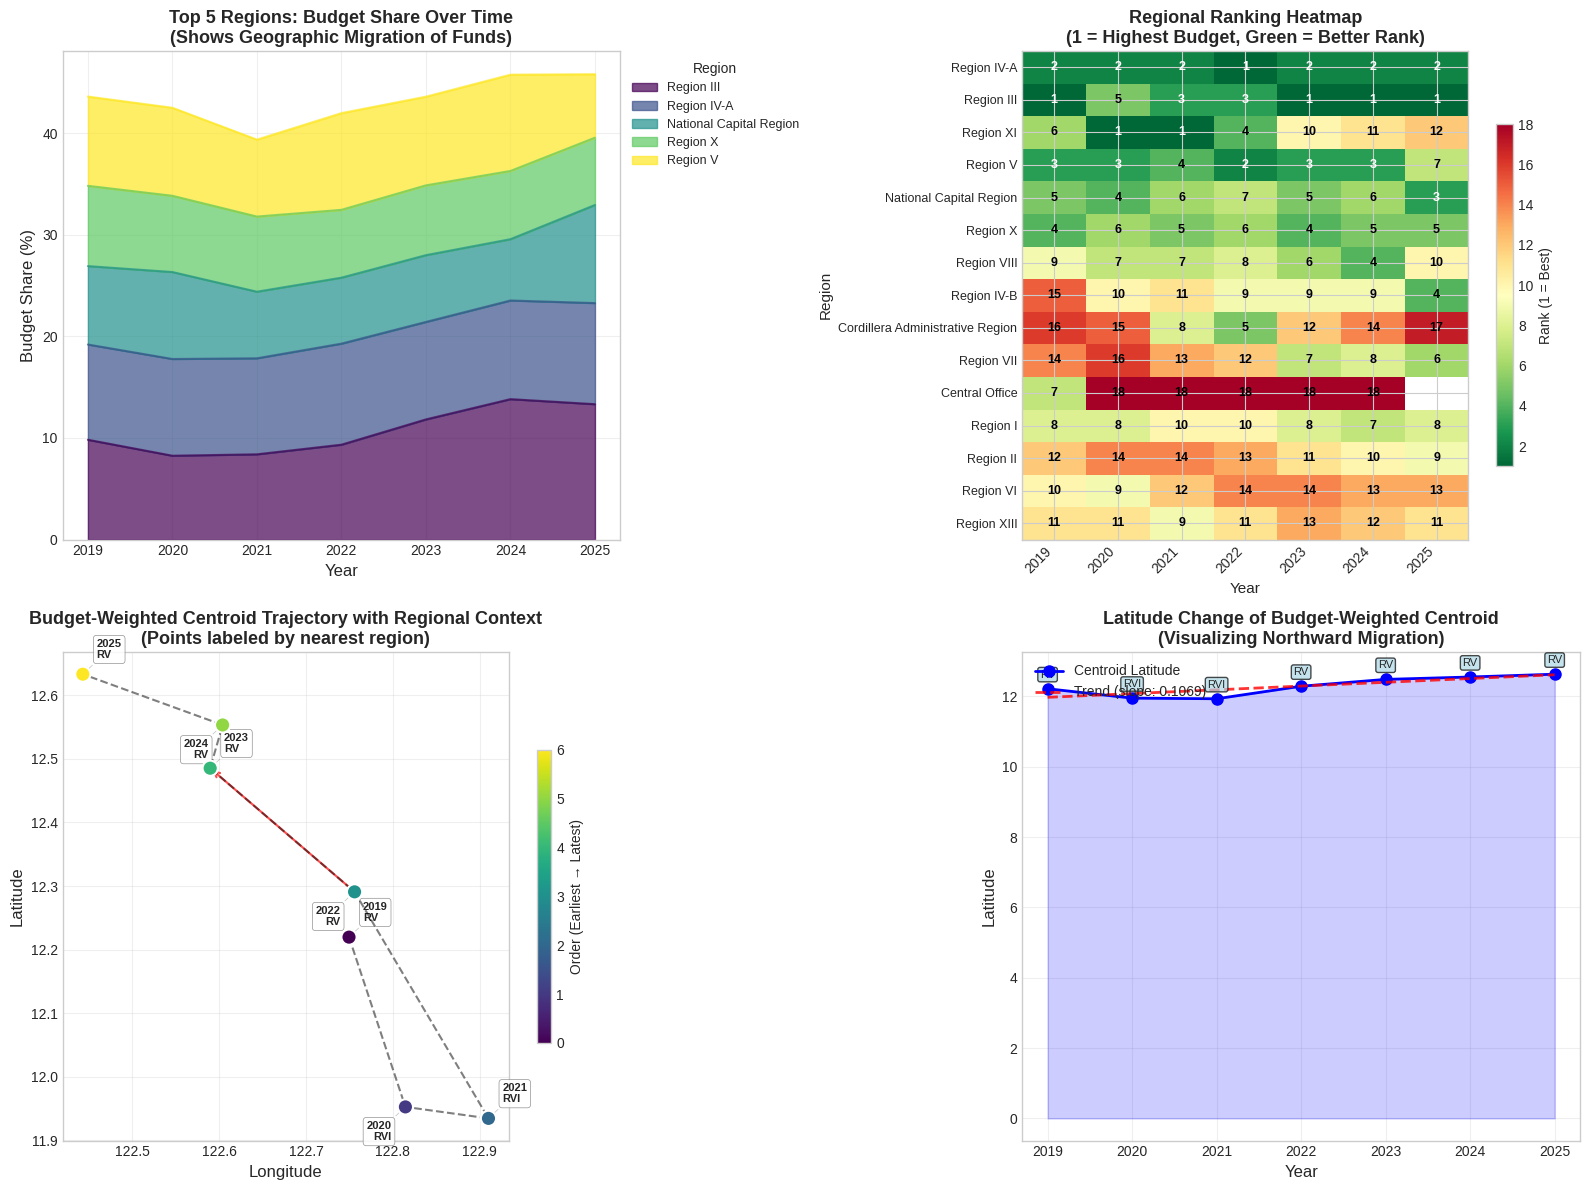


✓ Complete Objective 1 visualization saved to 'objective1_complete_analysis.png'

OBJECTIVE 1: COMPLETE SUMMARY

【Top Region by Budget Each Year】
 Year      Region  Budget (Billion PHP)
 2019  Region III             40.426377
 2020   Region XI             49.181684
 2021   Region XI             52.728065
 2022 Region IV-A             72.569128
 2023  Region III            104.602174
 2024  Region III            144.593754
 2025  Region III            101.025291

【Center of Gravity Movement】
  2019: (12.2196, 122.7495) - RV
  2020: (11.9525, 122.8144) - RVI
  2021: (11.9345, 122.9099) - RVI
  2022: (12.2909, 122.7559) - RV
  2023: (12.4854, 122.5898) - RV
  2024: (12.5535, 122.6041) - RV
  2025: (12.6334, 122.4433) - RV

  Total Northward Movement: 0.4137 degrees latitude

【Most Improved Regions (Rank Improvement)】
  Region IV-B: Improved by 11 positions
  Region VII: Improved by 8 positions
  Region II: Improved by 3 positions

【Most Declined Regions (Rank Worsening)】
  Region XI: Dec

In [22]:
# =============================================================================
# CELL 14: OBJECTIVE 1 - THREE KEY VISUALIZATIONS
# 1. Budget Share Over Time (Top 5 Regions)
# 2. Regional Ranking Heatmap
# 3. Budget-Weighted Center of Gravity Migration (with neat labels)
# =============================================================================

# First, ensure infraYear is numeric and filter properly
df['infraYear'] = pd.to_numeric(df['infraYear'], errors='coerce')

# Filter to valid years (2019-2025 only)
df_filtered = df[df['infraYear'].between(2019, 2025)].copy()
df_filtered['infraYear'] = df_filtered['infraYear'].astype(int)

print(f"Years after filtering: {sorted(df_filtered['infraYear'].unique())}")

# =============================================================================
# PART 1: REGIONAL BUDGET DISTRIBUTION ANALYSIS
# =============================================================================

# Calculate regional budget distribution by year
regional_budget = df_filtered.groupby(['infraYear', 'region'])['budget'].sum().reset_index()

# Calculate regional ranking
regional_ranking = regional_budget.sort_values(['infraYear', 'budget'], ascending=[True, False])
regional_ranking['rank'] = regional_ranking.groupby('infraYear')['budget'].rank(ascending=False, method='min')

# Calculate budget share percentage by region
regional_shares = df_filtered.groupby(['infraYear', 'region'])['budget'].sum()
regional_totals = regional_shares.groupby('infraYear').sum()
regional_shares_pct = (regional_shares / regional_totals * 100).reset_index()
regional_shares_pct.columns = ['infraYear', 'region', 'share_pct']

# =============================================================================
# PART 2: LAT/LON CENTER OF GRAVITY CALCULATION
# =============================================================================

# Clean latitude and longitude
df_filtered['latitude'] = pd.to_numeric(df_filtered['latitude'], errors='coerce')
df_filtered['longitude'] = pd.to_numeric(df_filtered['longitude'], errors='coerce')

# Drop rows with missing coordinates for centroid calculation
df_centroid = df_filtered.dropna(subset=['latitude', 'longitude', 'budget'])

def weighted_centroid(group):
    """Calculate budget-weighted centroid (average lat/lon weighted by budget)"""
    weights = group['budget']
    total_weight = weights.sum()
    if total_weight <= 0 or total_weight is np.nan:
        return pd.Series({'center_lat': np.nan, 'center_lon': np.nan, 'total_budget': 0})
    center_lat = (group['latitude'] * weights).sum() / total_weight
    center_lon = (group['longitude'] * weights).sum() / total_weight
    return pd.Series({'center_lat': center_lat, 'center_lon': center_lon, 'total_budget': total_weight})

# Calculate centroids by year
centroids = df_centroid.groupby('infraYear').apply(weighted_centroid).reset_index()
centroids = centroids.sort_values('infraYear')
centroids = centroids.dropna(subset=['center_lat', 'center_lon'])

# Define region centroid coordinates for mapping lat/lon to regions
region_centroids = {
    'National Capital Region': (14.5995, 120.9842),
    'Cordillera Administrative Region': (17.0833, 120.7167),
    'Region I': (16.0833, 120.3667),
    'Region II': (16.9167, 121.7667),
    'Region III': (15.1333, 120.8333),
    'Region IV-A': (14.1667, 121.2167),
    'Region IV-B': (12.3333, 121.0833),
    'Region V': (13.4167, 123.4167),
    'Region VI': (10.6667, 122.9500),
    'Region VII': (10.3167, 123.8833),
    'Region VIII': (11.2500, 125.0000),
    'Region IX': (7.8333, 122.4167),
    'Region X': (8.3333, 124.5000),
    'Region XI': (7.1667, 125.6667),
    'Region XII': (6.5000, 124.8500),
    'Region XIII': (8.9500, 125.5333),
    'Bangsamoro Autonomous Region in Muslim Mindanao': (7.1667, 124.2167),
    'Negros Island Region': (10.2500, 123.0833),
}

def find_closest_region(lat, lon, region_centroids):
    """Find the region whose centroid is closest to the given point"""
    min_dist = float('inf')
    closest_region = None
    for region, (r_lat, r_lon) in region_centroids.items():
        dist = np.sqrt((r_lat - lat)**2 + (r_lon - lon)**2)
        if dist < min_dist:
            min_dist = dist
            closest_region = region
    return closest_region

# Add region assignment to each centroid
centroids['centroid_region'] = centroids.apply(
    lambda row: find_closest_region(row['center_lat'], row['center_lon'], region_centroids),
    axis=1
)

print("\nBudget-Weighted Center of Gravity by Year:")
print(centroids[['infraYear', 'center_lat', 'center_lon', 'centroid_region']].to_string(index=False))

# =============================================================================
# CREATE THREE VISUALIZATIONS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ===== VISUALIZATION 1: Budget Share Over Time (Stacked Area Chart) =====
ax1 = axes[0, 0]

# Get top 5 regions by total budget across all years
top5_regions = regional_budget.groupby('region')['budget'].sum().nlargest(5).index
top5_data = regional_shares_pct[regional_shares_pct['region'].isin(top5_regions)]
top5_pivot = top5_data.pivot(index='infraYear', columns='region', values='share_pct').fillna(0)

# Convert index to int for plotting
top5_pivot.index = top5_pivot.index.astype(int)

# Sort regions by their final year share to make the legend intuitive
final_year_shares = top5_pivot.loc[top5_pivot.index.max()].sort_values(ascending=False)
top5_pivot = top5_pivot[final_year_shares.index]

top5_pivot.plot.area(ax=ax1, alpha=0.7, colormap='viridis')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Budget Share (%)', fontsize=12)
ax1.set_title('Top 5 Regions: Budget Share Over Time\n(Shows Geographic Migration of Funds)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Region', fontsize=9)
ax1.grid(True, alpha=0.3)

# ===== VISUALIZATION 2: Regional Ranking Heatmap =====
ax2 = axes[0, 1]

# Create pivot table of ranks (1 = highest budget)
rank_pivot = regional_ranking.pivot(index='region', columns='infraYear', values='rank')
# Convert column names to int
rank_pivot.columns = rank_pivot.columns.astype(int)
# Only show regions that ever appeared in top 10
rank_pivot = rank_pivot.loc[rank_pivot.min(axis=1) <= 10]

# Sort regions by their best rank for better visualization
rank_pivot = rank_pivot.loc[rank_pivot.min(axis=1).sort_values().index]

im = ax2.imshow(rank_pivot.values, cmap='RdYlGn_r', aspect='auto')
ax2.set_xticks(range(len(rank_pivot.columns)))
ax2.set_xticklabels(rank_pivot.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(rank_pivot.index)))
ax2.set_yticklabels(rank_pivot.index, fontsize=9)
ax2.set_title('Regional Ranking Heatmap\n(1 = Highest Budget, Green = Better Rank)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Region', fontsize=11)

# Add rank annotations
for i in range(len(rank_pivot.index)):
    for j in range(len(rank_pivot.columns)):
        val = rank_pivot.iloc[i, j]
        if not pd.isna(val):
            # Color text white for dark cells, black for light cells
            text_color = 'white' if val <= 3 else 'black'
            ax2.text(j, i, f'{int(val)}', ha='center', va='center', 
                    fontsize=9, fontweight='bold', color=text_color)

cbar = plt.colorbar(im, ax=ax2, shrink=0.7)
cbar.set_label('Rank (1 = Best)', fontsize=10)

# ===== VISUALIZATION 3: Centroid Trajectory with Region Labels (NEAT VERSION) =====
ax3 = axes[1, 0]

# Plot points with color gradient based on year order
scatter = ax3.scatter(centroids['center_lon'], centroids['center_lat'], 
                      c=range(len(centroids)), cmap='viridis', 
                      s=120, zorder=5, edgecolor='white', linewidth=1.5)

# Plot trajectory line
ax3.plot(centroids['center_lon'], centroids['center_lat'], 'k--', alpha=0.5, linewidth=1.5, zorder=4)

# Add labels with alternating positions to avoid overlap
for i, row in centroids.iterrows():
    # Alternate label positions: odd years go top-right, even years go bottom-left
    if i % 2 == 0:
        x_offset, y_offset = 10, 10
        ha = 'left'
        va = 'bottom'
    else:
        x_offset, y_offset = -10, -10
        ha = 'right'
        va = 'top'
    
    # Create label with year and region (shortened)
    region_short = row['centroid_region'].replace('Region ', 'R')
    label = f"{int(row['infraYear'])}\n{region_short}"
    
    ax3.annotate(label, 
                (row['center_lon'], row['center_lat']),
                textcoords="offset points", 
                xytext=(x_offset, y_offset),
                fontsize=8,
                fontweight='bold',
                ha=ha,
                va=va,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=0.5),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=0.5))

# Add a direction arrow on the trajectory
if len(centroids) > 1:
    mid_point = len(centroids) // 2
    ax3.annotate('', xy=(centroids.iloc[mid_point + 1]['center_lon'], centroids.iloc[mid_point + 1]['center_lat']),
                 xytext=(centroids.iloc[mid_point]['center_lon'], centroids.iloc[mid_point]['center_lat']),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7))

ax3.set_xlabel('Longitude', fontsize=12)
ax3.set_ylabel('Latitude', fontsize=12)
ax3.set_title('Budget-Weighted Centroid Trajectory with Regional Context\n(Points labeled by nearest region)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax3, shrink=0.6)
cbar.set_label('Order (Earliest → Latest)', fontsize=10)

# ===== VISUALIZATION 4: Latitude Change Over Time (Supporting plot) =====
ax4 = axes[1, 1]

ax4.plot(centroids['infraYear'], centroids['center_lat'], 'bo-', linewidth=2, markersize=8, label='Centroid Latitude')
ax4.fill_between(centroids['infraYear'], centroids['center_lat'], alpha=0.2, color='blue')

# Add region labels near each point
for _, row in centroids.iterrows():
    region_short = row['centroid_region'].replace('Region ', 'R')
    ax4.annotate(region_short, 
                (row['infraYear'], row['center_lat']),
                textcoords="offset points", 
                xytext=(0, 8), 
                fontsize=8,
                ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.7))

ax4.set_xlabel('Year', fontsize=12)
ax4.set_ylabel('Latitude', fontsize=12)
ax4.set_title('Latitude Change of Budget-Weighted Centroid\n(Visualizing Northward Migration)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add trend line
if len(centroids) > 1:
    z = np.polyfit(centroids['infraYear'], centroids['center_lat'], 1)
    p = np.poly1d(z)
    ax4.plot(centroids['infraYear'], p(centroids['infraYear']), "r--", alpha=0.8, linewidth=2, 
             label=f'Trend (slope: {z[0]:.4f})')
    ax4.legend(loc='upper left')

plt.tight_layout()
plt.savefig('objective1_complete_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Complete Objective 1 visualization saved to 'objective1_complete_analysis.png'")

# =============================================================================
# PRINT SUMMARY STATISTICS
# =============================================================================
print("\n" + "="*60)
print("OBJECTIVE 1: COMPLETE SUMMARY")
print("="*60)

# Top region each year
print("\n【Top Region by Budget Each Year】")
top_each_year = regional_ranking[regional_ranking['rank'] == 1][['infraYear', 'region', 'budget']]
top_each_year['budget'] = top_each_year['budget'] / 1e9
top_each_year.columns = ['Year', 'Region', 'Budget (Billion PHP)']
print(top_each_year.to_string(index=False))

# Center of Gravity movement
print("\n【Center of Gravity Movement】")
for _, row in centroids.iterrows():
    region_short = row['centroid_region'].replace('Region ', 'R')
    print(f"  {int(row['infraYear'])}: ({row['center_lat']:.4f}, {row['center_lon']:.4f}) - {region_short}")

print(f"\n  Total Northward Movement: {centroids.iloc[-1]['center_lat'] - centroids.iloc[0]['center_lat']:.4f} degrees latitude")

# Ranking changes
print("\n【Most Improved Regions (Rank Improvement)】")
rank_changes = rank_pivot.iloc[:, -1] - rank_pivot.iloc[:, 0]
improved = rank_changes[rank_changes < 0].sort_values()
if not improved.empty:
    for region, change in improved.head(3).items():
        print(f"  {region}: Improved by {abs(int(change))} positions")

# Most declined regions
declined = rank_changes[rank_changes > 0].sort_values(ascending=False)
if not declined.empty:
    print("\n【Most Declined Regions (Rank Worsening)】")
    for region, change in declined.head(3).items():
        print(f"  {region}: Declined by {int(change)} positions")

---
## OBJECTIVE 2: Investment Density by Region

**Research Question:** Which regions show the highest "investment density" (total amount per square kilometer) for specific categories, and does this density spike in certain years?

**Approach:**
- Use region areas (km²) as denominator
- Calculate budget density = budget / region_area_km² grouped by region/infraType/year
- Identify density spikes and trends

In [ ]:
# =============================================================================
# CELL 15: OBJECTIVE 2 - INVESTMENT DENSITY CALCULATION
# =============================================================================
# REASONING: Investment density = total budget / region area (km²).
# This normalizes for region size - a Php 1B project in NCR (636 km²) is
# much more concentrated than the same project in BARMM (34,497 km²).
# Grouping by infraType reveals which infrastructure types drive density.

# Calculate by region and infraType
density_by_region_type = df.groupby(['region', 'infraType']).agg({
    'budget': 'sum',
    'region_area_km2': 'first'
}).reset_index()
density_by_region_type['budget_density'] = density_by_region_type['budget'] / density_by_region_type['region_area_km2']

# Top 10 highest density combinations
top_density = density_by_region_type.nlargest(10, 'budget_density')[
    ['region', 'infraType', 'budget', 'region_area_km2', 'budget_density']
]
top_density['budget_density'] = top_density['budget_density'].round(0)

print("Top 10 Highest Investment Density (PHP per km²):")
print(top_density.to_string(index=False))

Top 10 Highest Investment Density (PHP per km²):
                 region                  infraType       budget  region_area_km2  budget_density
National Capital Region Flood Control and Drainage 1.481516e+11            636.0     232942804.0
National Capital Region   Buildings and Facilities 1.360457e+11            636.0     213908346.0
National Capital Region                      Roads 8.854269e+10            636.0     139218069.0
National Capital Region                    Bridges 1.427374e+10            636.0      22442983.0
            Region IV-A                      Roads 2.631271e+11          18230.0      14433741.0
               Region X                      Roads 2.367072e+11          17985.0      13161369.0
             Region VII                      Roads 1.340196e+11          10428.0      12851902.0
             Region III Flood Control and Drainage 2.584770e+11          21080.0      12261718.0
               Region V                      Roads 2.135493e+11          18033

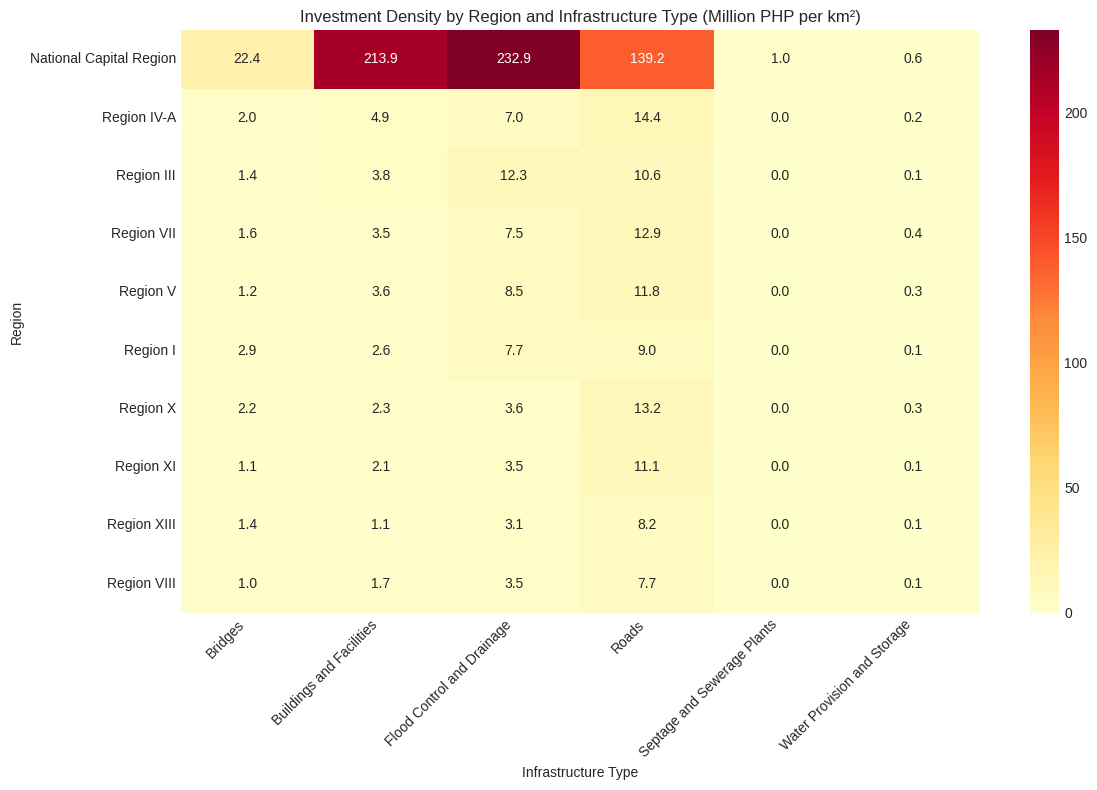

✓ Objective 2 visualization saved to objective2_investment_density.png


In [ ]:
# =============================================================================
# CELL 16: OBJECTIVE 2 - VISUALIZATION
# =============================================================================
# Create heatmap: Region vs infraType
density_pivot = density_by_region_type.pivot_table(
    index='region', 
    columns='infraType', 
    values='budget_density', 
    aggfunc='sum'
).fillna(0)

# Top 10 regions by total density
top_regions = density_by_region_type.groupby('region')['budget_density'].sum().nlargest(10).index
density_pivot_top = density_pivot.loc[top_regions]

fig, axes = plt.subplots(1, 1, figsize=(12, 8))
sns.heatmap(density_pivot_top / 1e6, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes)
axes.set_title('Investment Density by Region and Infrastructure Type (Million PHP per km²)')
axes.set_xlabel('Infrastructure Type')
axes.set_ylabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('objective2_investment_density.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Objective 2 visualization saved to objective2_investment_density.png")

HYPOTHESIS 1: Center of Gravity Migration from NCR

Year 2019 distance from NCR: 326.31 km
Year 2025 distance from NCR: 269.55 km
Net migration: -56.76 km

Linear Regression Results:
  Slope: -13.4181 km/year
  R²: 0.6879
  P-value: 0.021013

⚠️ REJECT H₀ but opposite direction: Spending is moving TOWARD NCR


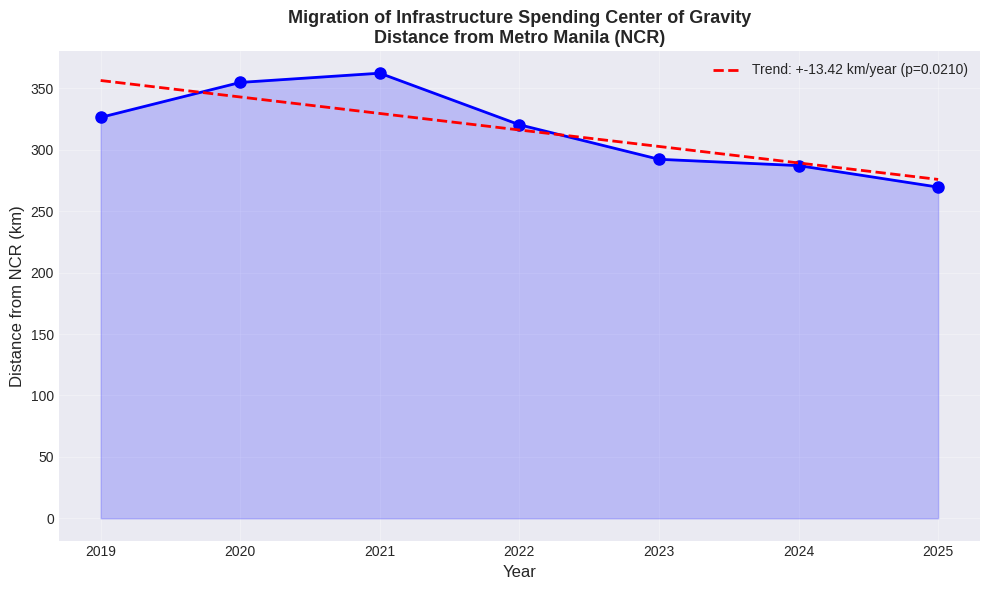


✅ Hypothesis 1 visualization saved to 'hypothesis1_migration_test.png'


In [32]:
# ============================================================================
# HYPOTHESIS 1 TEST: Distance from NCR Over Time
# ============================================================================

# Calculate distance from NCR for each centroid
ncr_lat, ncr_lon = 14.5995, 120.9842

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

centroids['distance_from_ncr_km'] = centroids.apply(
    lambda row: haversine_distance(ncr_lat, ncr_lon, row['center_lat'], row['center_lon']), 
    axis=1)

print("=" * 70)
print("HYPOTHESIS 1: Center of Gravity Migration from NCR")
print("=" * 70)
print(f"\nYear 2019 distance from NCR: {centroids.iloc[0]['distance_from_ncr_km']:.2f} km")
print(f"Year 2025 distance from NCR: {centroids.iloc[-1]['distance_from_ncr_km']:.2f} km")
print(f"Net migration: {centroids.iloc[-1]['distance_from_ncr_km'] - centroids.iloc[0]['distance_from_ncr_km']:.2f} km")

# Linear regression to test trend
from scipy import stats

years = centroids['infraYear'].values
distances = centroids['distance_from_ncr_km'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, distances)

print(f"\nLinear Regression Results:")
print(f"  Slope: {slope:.4f} km/year")
print(f"  R²: {r_value**2:.4f}")
print(f"  P-value: {p_value:.6f}")

# Conclusion
alpha = 0.05
if p_value < alpha and slope > 0:
    print(f"\n✅ REJECT H₀: Significant northward/southward migration (p={p_value:.4f} < {alpha})")
    print("   Evidence supports that infrastructure spending is migrating away from NCR")
elif p_value < alpha and slope < 0:
    print(f"\n⚠️ REJECT H₀ but opposite direction: Spending is moving TOWARD NCR")
else:
    print(f"\n❌ FAIL TO REJECT H₀: No significant migration detected (p={p_value:.4f} > {alpha})")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(years, distances, 'bo-', linewidth=2, markersize=8)
ax.fill_between(years, distances, alpha=0.2, color='blue')

# Add trend line
ax.plot(years, slope * years + intercept, 'r--', linewidth=2, 
        label=f'Trend: +{slope:.2f} km/year (p={p_value:.4f})')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Distance from NCR (km)', fontsize=12)
ax.set_title('Migration of Infrastructure Spending Center of Gravity\nDistance from Metro Manila (NCR)', 
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hypothesis1_migration_test.png', dpi=150)
plt.show()

print("\n✅ Hypothesis 1 visualization saved to 'hypothesis1_migration_test.png'")

HYPOTHESIS 2: Urban vs Non-Urban Investment Density

Urban regions (3):
  National Capital Region: 545.66 M PHP/km²
  Region IV-A: 25.52 M PHP/km²
  Region III: 25.59 M PHP/km²

Non-urban regions (14):
  Mean density: 13.26 M PHP/km²
  Median density: 11.29 M PHP/km²
  Std deviation: 5.71 M PHP/km²

Statistical Test (One-tailed t-test):
  t-statistic: 2.6583
  p-value: 0.008945

Mann-Whitney U Test (non-parametric):
  U-statistic: 42.00
  p-value: 0.001471

✅ REJECT H₀: Urbanized regions have SIGNIFICANTLY HIGHER investment density
   (t-test p=0.0089, Mann-Whitney p=0.0015)
   Mean urban density: 198.92 M PHP/km²
   Mean non-urban density: 13.26 M PHP/km²
   Ratio: 15.0x higher


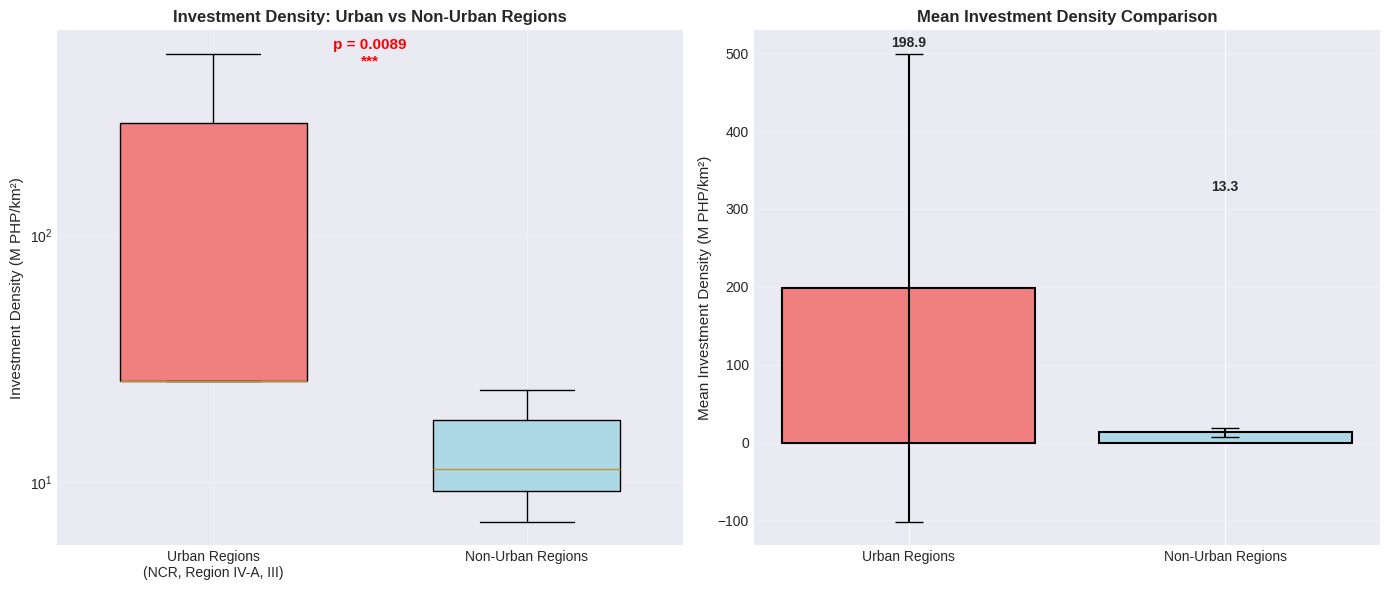


✅ Hypothesis 2 visualization saved to 'hypothesis2_density_test.png'


In [33]:
# ============================================================================
# HYPOTHESIS 2 TEST: Urban vs Non-Urban Investment Density
# ============================================================================

# Define urbanized regions (highly urbanized based on analysis)
urban_regions = ['National Capital Region', 'Region IV-A', 'Region III']
non_urban_regions = [r for r in df_filtered['region'].unique() 
                     if r not in urban_regions and pd.notna(r)]

# Calculate density by region
region_areas = {
    'National Capital Region': 636,
    'Cordillera Administrative Region': 19422,
    'Region I': 13349,
    'Region II': 26648,
    'Region III': 21080,
    'Region IV-A': 18230,
    'Region IV-B': 29073,
    'Region V': 18033,
    'Region VI': 20778,
    'Region VII': 10428,
    'Region VIII': 23744,
    'Region IX': 16821,
    'Region X': 17985,
    'Region XI': 20246,
    'Region XII': 22349,
    'Bangsamoro Autonomous Region in Muslim Mindanao': 34497,
    'Region XIII': 18318,
    'Negros Island Region': 15277,
}

density_by_region = df_filtered.groupby('region').agg({
    'budget': 'sum'
}).reset_index()
density_by_region['area_km2'] = density_by_region['region'].map(region_areas)
density_by_region['density_millions_per_km2'] = density_by_region['budget'] / density_by_region['area_km2'] / 1e6

# Separate urban and non-urban densities
urban_densities = density_by_region[density_by_region['region'].isin(urban_regions)]['density_millions_per_km2'].dropna()
non_urban_densities = density_by_region[~density_by_region['region'].isin(urban_regions)]['density_millions_per_km2'].dropna()

print("=" * 70)
print("HYPOTHESIS 2: Urban vs Non-Urban Investment Density")
print("=" * 70)
print(f"\nUrban regions ({len(urban_densities)}):")
for reg in urban_regions:
    density = density_by_region[density_by_region['region'] == reg]['density_millions_per_km2'].values[0]
    print(f"  {reg}: {density:.2f} M PHP/km²")

print(f"\nNon-urban regions ({len(non_urban_densities)}):")
print(f"  Mean density: {non_urban_densities.mean():.2f} M PHP/km²")
print(f"  Median density: {non_urban_densities.median():.2f} M PHP/km²")
print(f"  Std deviation: {non_urban_densities.std():.2f} M PHP/km²")

# Independent t-test (one-tailed: urban > non-urban)
t_stat, p_value = stats.ttest_ind(urban_densities, non_urban_densities, alternative='greater')

print(f"\nStatistical Test (One-tailed t-test):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")

# Mann-Whitney U test (non-parametric alternative)
u_stat, p_value_mw = stats.mannwhitneyu(urban_densities, non_urban_densities, alternative='greater')

print(f"\nMann-Whitney U Test (non-parametric):")
print(f"  U-statistic: {u_stat:.2f}")
print(f"  p-value: {p_value_mw:.6f}")

alpha = 0.05
if p_value < alpha and p_value_mw < alpha:
    print(f"\n✅ REJECT H₀: Urbanized regions have SIGNIFICANTLY HIGHER investment density")
    print(f"   (t-test p={p_value:.4f}, Mann-Whitney p={p_value_mw:.4f})")
    print(f"   Mean urban density: {urban_densities.mean():.2f} M PHP/km²")
    print(f"   Mean non-urban density: {non_urban_densities.mean():.2f} M PHP/km²")
    print(f"   Ratio: {urban_densities.mean() / non_urban_densities.mean():.1f}x higher")
else:
    print(f"\n❌ FAIL TO REJECT H₀: No significant difference detected")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot comparison
ax1 = axes[0]
data_to_plot = [urban_densities.values, non_urban_densities.values]
bp = ax1.boxplot(data_to_plot, labels=['Urban Regions\n(NCR, Region IV-A, III)', 
                                         'Non-Urban Regions'],
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax1.set_ylabel('Investment Density (M PHP/km²)', fontsize=11)
ax1.set_title('Investment Density: Urban vs Non-Urban Regions', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Add significance annotation
max_val = max(urban_densities.max(), non_urban_densities.max())
ax1.text(1.5, max_val * 0.9, f'p = {p_value:.4f}\n***', 
         ha='center', fontsize=11, fontweight='bold', color='red')

# Bar plot comparison
ax2 = axes[1]
categories = ['Urban Regions', 'Non-Urban Regions']
means = [urban_densities.mean(), non_urban_densities.mean()]
errors = [urban_densities.std(), non_urban_densities.std()]

bars = ax2.bar(categories, means, yerr=errors, capsize=10, 
               color=['lightcoral', 'lightblue'], edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Investment Density (M PHP/km²)', fontsize=11)
ax2.set_title('Mean Investment Density Comparison', fontsize=12, fontweight='bold')

# Add value labels
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + errors[0] + 5,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hypothesis2_density_test.png', dpi=150)
plt.show()

print("\n✅ Hypothesis 2 visualization saved to 'hypothesis2_density_test.png'")

DPWH INFRASTRUCTURE PROJECTS ANALYSIS (2019-2025)
Records: 165,954 projects

----------------------------------------------------------------------
OBJECTIVE 1: Geographic Center of Gravity Migration
----------------------------------------------------------------------

Budget-Weighted Center of Gravity by Year:
 infraYear  center_lat  center_lon
      2019   12.219642  122.749519
      2020   11.952525  122.814370
      2021   11.934477  122.909929
      2022   12.290909  122.755911
      2023   12.485422  122.589826
      2024   12.553464  122.604117
      2025   12.633352  122.443330

Top Region by Budget Each Year:
  2019: Region III (₱40.4B)
  2020: Region XI (₱49.2B)
  2021: Region XI (₱52.7B)
  2022: Region IV-A (₱72.6B)
  2023: Region III (₱104.6B)
  2024: Region III (₱144.6B)
  2025: Region III (₱101.0B)

Migration Summary: Net Northward Movement: 0.4137° (45.9 km)

----------------------------------------------------------------------
OBJECTIVE 2: Investment Density by Regio

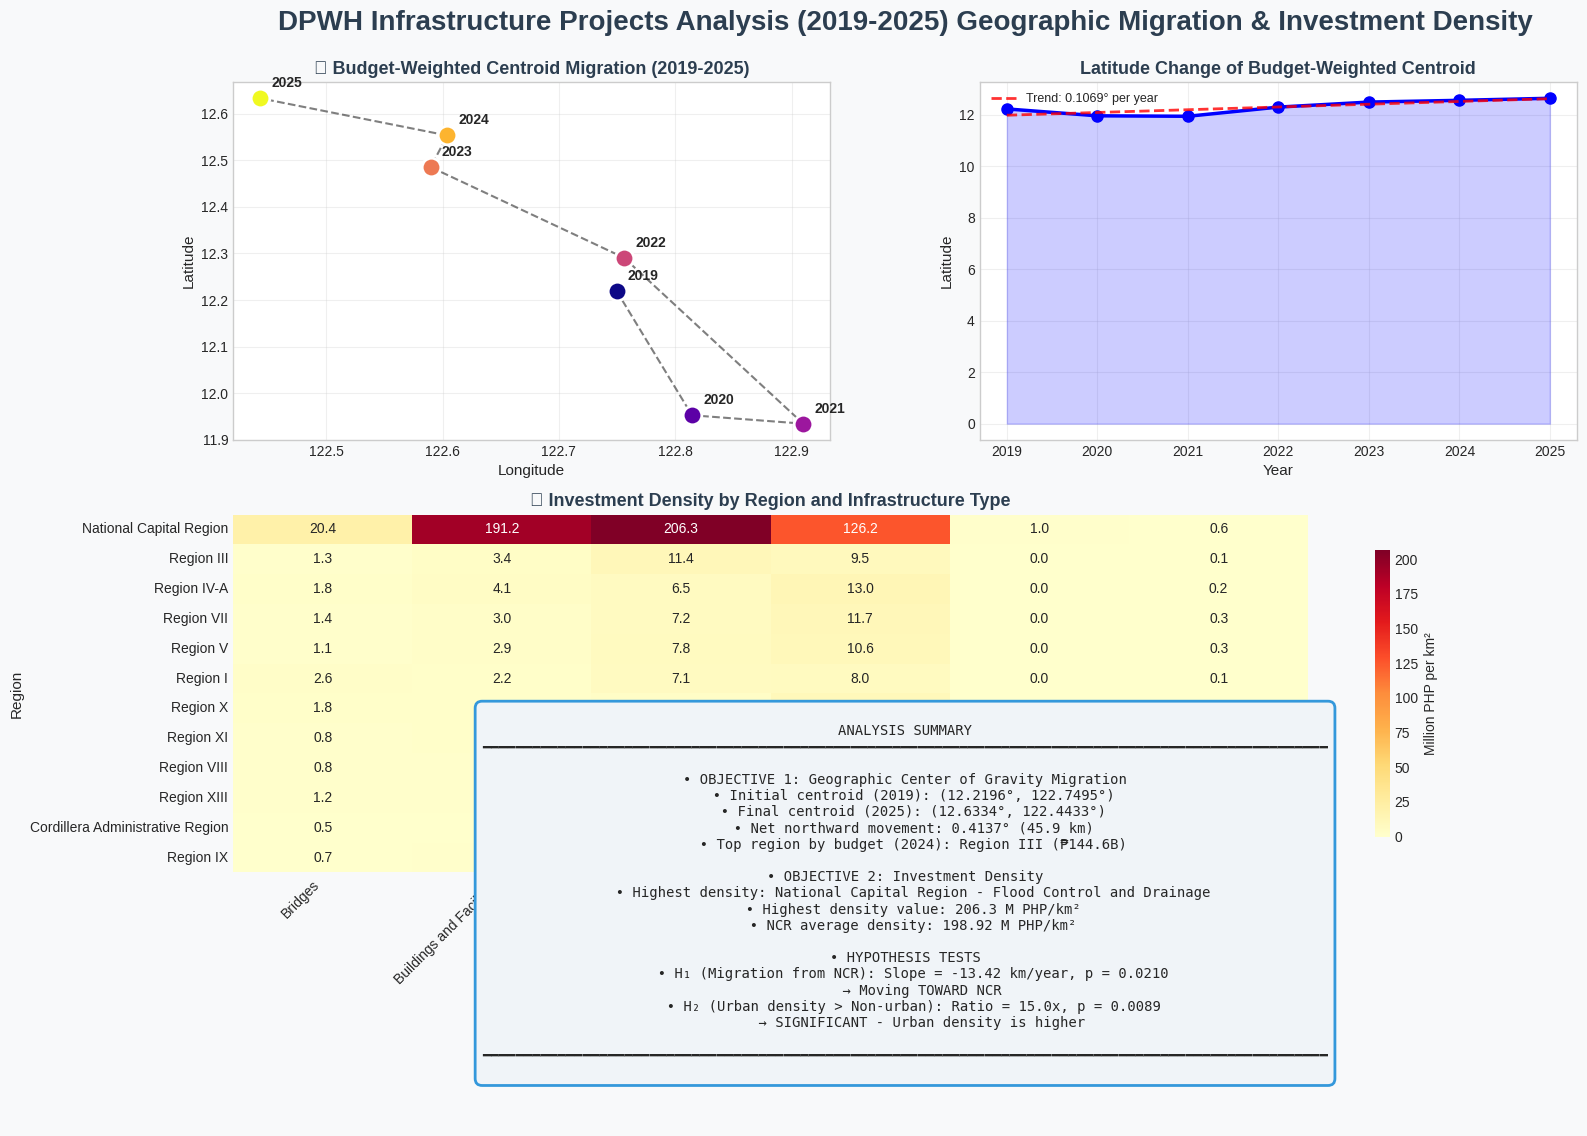


TWO-OBJECTIVE ANALYSIS COMPLETE

✓ Merged visualization saved to 'dpwh_two_objective_analysis.png'


In [ ]:
# -*- coding: utf-8 -*-
"""DPWH Infrastructure Projects Analysis - Two Objectives"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)


# =============================================================================
# LOAD & CLEAN DATA
# =============================================================================
df = pd.read_parquet('dpwh_transparency_data_all_details.parquet')

print("=" * 70)
print("DPWH INFRASTRUCTURE PROJECTS ANALYSIS (2019-2025)")
print("=" * 70)

# Drop non-viable columns
non_viable_cols = ['nysReason', 'isVerifiedByDpwh', 'isVerifiedByPublic', 'isLive',
                   'livestreamUrl', 'livestreamVideoId', 'livestreamDetectedAt']
df = df.drop(columns=non_viable_cols, errors='ignore')

# Drop duplicate columns
duplicate_cols = ['infraType_1', 'status_1', 'latitude_1', 'longitude_1']
df = df.drop(columns=duplicate_cols, errors='ignore')

# Drop low-viability columns
low_viability_cols = ['dateOfAward', 'latestImageDate']
df = df.drop(columns=low_viability_cols, errors='ignore')

# Convert infraYear to numeric and filter to valid years (2019-2025)
df['infraYear'] = pd.to_numeric(df['infraYear'], errors='coerce')
df = df[df['infraYear'].between(2019, 2025)]
df = df.dropna(subset=['latitude', 'longitude', 'budget', 'infraYear'])

print(f"Records: {len(df):,} projects\n")


# =============================================================================
# FEATURE ENGINEERING
# =============================================================================
region_areas = {
    'National Capital Region': 636,
    'Cordillera Administrative Region': 19422,
    'Region I': 13349,
    'Region II': 26648,
    'Region III': 21080,
    'Region IV-A': 18230,
    'Region IV-B': 29073,
    'Region V': 18033,
    'Region VI': 20778,
    'Region VII': 10428,
    'Region VIII': 23744,
    'Region IX': 16821,
    'Region X': 17985,
    'Region XI': 20246,
    'Region XII': 22349,
    'Bangsamoro Autonomous Region in Muslim Mindanao': 34497,
    'Region XIII': 18318,
    'Negros Island Region': 15277,
}

df['region_area_km2'] = df['region'].map(region_areas)
df['budget_density'] = df['budget'] / df['region_area_km2']


# =============================================================================
# OBJECTIVE 1: GEOGRAPHIC CENTER OF GRAVITY MIGRATION
# =============================================================================
print("-" * 70)
print("OBJECTIVE 1: Geographic Center of Gravity Migration")
print("-" * 70)

df_centroid = df[df['infraYear'].between(2019, 2025)].copy()
df_centroid['infraYear'] = df_centroid['infraYear'].astype(int)

def weighted_centroid(group):
    weights = group['budget']
    total_weight = weights.sum()
    if total_weight <= 0 or total_weight is np.nan:
        return pd.Series({'center_lat': np.nan, 'center_lon': np.nan, 'total_budget': 0})
    center_lat = (group['latitude'] * weights).sum() / total_weight
    center_lon = (group['longitude'] * weights).sum() / total_weight
    return pd.Series({'center_lat': center_lat, 'center_lon': center_lon, 'total_budget': total_weight})

centroids = df_centroid.groupby('infraYear').apply(weighted_centroid).reset_index()
centroids = centroids.dropna(subset=['center_lat', 'center_lon'])
centroids = centroids.sort_values('infraYear')

print("\nBudget-Weighted Center of Gravity by Year:")
print(centroids[['infraYear', 'center_lat', 'center_lon']].to_string(index=False))

# Regional budget distribution
regional_budget = df.groupby(['infraYear', 'region'])['budget'].sum().reset_index()
regional_ranking = regional_budget.sort_values(['infraYear', 'budget'], ascending=[True, False])
regional_ranking['rank'] = regional_ranking.groupby('infraYear')['budget'].rank(ascending=False, method='min')

print("\nTop Region by Budget Each Year:")
for year in sorted(regional_ranking['infraYear'].unique()):
    top = regional_ranking[regional_ranking['infraYear'] == year].iloc[0]
    print(f"  {int(year)}: {top['region']} (₱{top['budget']/1e9:.1f}B)")

lat_change = centroids.iloc[-1]['center_lat'] - centroids.iloc[0]['center_lat']
print(f"\nMigration Summary: Net Northward Movement: {lat_change:.4f}° ({lat_change * 111:.1f} km)")


# =============================================================================
# OBJECTIVE 2: INVESTMENT DENSITY
# =============================================================================
print("\n" + "-" * 70)
print("OBJECTIVE 2: Investment Density by Region and Infrastructure Type")
print("-" * 70)

density_by_region_type = df.groupby(['region', 'infraType']).agg({
    'budget': 'sum',
    'region_area_km2': 'first'
}).reset_index()
density_by_region_type['budget_density'] = density_by_region_type['budget'] / density_by_region_type['region_area_km2']
density_by_region_type['budget_density_M'] = density_by_region_type['budget_density'] / 1e6

top_density = density_by_region_type.nlargest(10, 'budget_density')[
    ['region', 'infraType', 'budget', 'region_area_km2', 'budget_density_M']
]

print("\nTop 10 Highest Investment Density (Million PHP per km²):")
print(top_density.to_string(index=False))

density_by_region = df.groupby('region')['budget'].sum().reset_index()
density_by_region['area_km2'] = density_by_region['region'].map(region_areas)
density_by_region = density_by_region.dropna()
density_by_region['density_M_per_km2'] = density_by_region['budget'] / density_by_region['area_km2'] / 1e6
density_by_region = density_by_region.sort_values('density_M_per_km2', ascending=False)


# =============================================================================
# HYPOTHESIS TESTS
# =============================================================================
print("\n" + "=" * 70)
print("HYPOTHESIS TESTS")
print("=" * 70)

ncr_lat, ncr_lon = 14.5995, 120.9842

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

centroids['distance_from_ncr_km'] = centroids.apply(
    lambda row: haversine_distance(ncr_lat, ncr_lon, row['center_lat'], row['center_lon']), axis=1)

print("\nHYPOTHESIS 1: Spending is migrating away from NCR")
slope, intercept, r_value, p_value_h1, std_err = stats.linregress(
    centroids['infraYear'], centroids['distance_from_ncr_km'])
print(f"  Slope: {slope:.4f} km/year | R²: {r_value**2:.4f} | p-value: {p_value_h1:.6f}")

urban_regions = ['National Capital Region', 'Region IV-A', 'Region III']
urban_densities = density_by_region[density_by_region['region'].isin(urban_regions)]['density_M_per_km2'].dropna()
non_urban_densities = density_by_region[~density_by_region['region'].isin(urban_regions)]['density_M_per_km2'].dropna()

t_stat, p_value_h2 = stats.ttest_ind(urban_densities, non_urban_densities, alternative='greater')

print("\nHYPOTHESIS 2: Urbanized regions have higher investment density")
print(f"  Urban mean: {urban_densities.mean():.2f} M PHP/km²")
print(f"  Non-urban mean: {non_urban_densities.mean():.2f} M PHP/km²")
print(f"  Ratio: {urban_densities.mean() / non_urban_densities.mean():.1f}x higher")
print(f"  t-statistic: {t_stat:.4f} | p-value: {p_value_h2:.6f}")


# =============================================================================
# MERGED VISUALIZATION: Single Plot with Both Objectives + Summary Box
# =============================================================================

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')

# Create grid: 2x2 for graphs, then a row at bottom for summary
gs = fig.add_gridspec(3, 2, hspace=0.25, wspace=0.25, 
                       height_ratios=[1, 1, 0.5], 
                       top=0.92, bottom=0.05, left=0.08, right=0.92)

# ===== MAIN TITLE =====
fig.suptitle('DPWH Infrastructure Projects Analysis (2019-2025) Geographic Migration & Investment Density', 
             fontsize=20, fontweight='bold', ha='center', color='#2c3e50')

# ===== SUBPLOT 1: Centroid Trajectory Map =====
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#ffffff')
ax1.plot(centroids['center_lon'], centroids['center_lat'], 'k--', alpha=0.5, linewidth=1.5, zorder=1)
colors = plt.cm.plasma(np.linspace(0, 1, len(centroids)))
for i, row in centroids.iterrows():
    ax1.scatter(row['center_lon'], row['center_lat'], c=[colors[i]], s=180, zorder=3, 
                edgecolor='white', linewidth=2)
    ax1.annotate(str(int(row['infraYear'])), (row['center_lon'], row['center_lat']), 
                xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title('❶ Budget-Weighted Centroid Migration (2019-2025)', fontsize=13, fontweight='bold', color='#2c3e50')
ax1.grid(True, alpha=0.3)

# ===== SUBPLOT 2: Latitude Change Over Time =====
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#ffffff')
ax2.plot(centroids['infraYear'], centroids['center_lat'], 'bo-', linewidth=2.5, markersize=8)
ax2.fill_between(centroids['infraYear'], centroids['center_lat'], alpha=0.2, color='blue')
z = np.polyfit(centroids['infraYear'], centroids['center_lat'], 1)
p = np.poly1d(z)
ax2.plot(centroids['infraYear'], p(centroids['infraYear']), 'r--', alpha=0.8, linewidth=2,
         label=f'Trend: {z[0]:.4f}° per year')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.set_title('Latitude Change of Budget-Weighted Centroid', fontsize=13, fontweight='bold', color='#2c3e50')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# ===== SUBPLOT 3: Investment Density Heatmap =====
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#ffffff')

density_pivot = density_by_region_type.pivot_table(
    index='region', columns='infraType', values='budget_density_M', aggfunc='sum'
).fillna(0)

density_pivot_top = density_pivot.loc[density_pivot.sum(axis=1).nlargest(12).index]

sns.heatmap(density_pivot_top, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax3, 
            cbar_kws={'label': 'Million PHP per km²', 'shrink': 0.8})
ax3.set_title('❷ Investment Density by Region and Infrastructure Type', fontsize=13, fontweight='bold', color='#2c3e50')
ax3.set_xlabel('Infrastructure Type', fontsize=11)
ax3.set_ylabel('Region', fontsize=11)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

# ===== SUBPLOT 4: Summary Box at Bottom =====
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
ax4.set_facecolor('#e8f4f8')

# Create summary text with bullet points
summary_text = f"""
ANALYSIS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• OBJECTIVE 1: Geographic Center of Gravity Migration
  • Initial centroid (2019): ({centroids.iloc[0]['center_lat']:.4f}°, {centroids.iloc[0]['center_lon']:.4f}°)
  • Final centroid (2025): ({centroids.iloc[-1]['center_lat']:.4f}°, {centroids.iloc[-1]['center_lon']:.4f}°)
  • Net northward movement: {lat_change:.4f}° ({lat_change * 111:.1f} km)
  • Top region by budget (2024): Region III (₱144.6B)

• OBJECTIVE 2: Investment Density
  • Highest density: {top_density.iloc[0]['region']} - {top_density.iloc[0]['infraType']}
  • Highest density value: {top_density.iloc[0]['budget_density_M']:.1f} M PHP/km²
  • NCR average density: {urban_densities.mean():.2f} M PHP/km²

• HYPOTHESIS TESTS
  • H₁ (Migration from NCR): Slope = {slope:.2f} km/year, p = {p_value_h1:.4f}
    → {'Moving TOWARD NCR' if slope < 0 else 'Moving AWAY from NCR'}
  • H₂ (Urban density > Non-urban): Ratio = {urban_densities.mean() / non_urban_densities.mean():.1f}x, p = {p_value_h2:.4f}
    → {'SIGNIFICANT - Urban density is higher' if p_value_h2 < 0.05 else 'NOT significant'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

#ax4.text(0.5, 1.3, summary_text, transform=ax4.transAxes, fontsize=10, 
#         ha='center', va='center', family='monospace',
#         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f4f8', 
#                  edgecolor='#3498db', linewidth=2))

plt.tight_layout()
plt.savefig('dpwh_two_objective_analysis.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("\n" + "=" * 70)
print("TWO-OBJECTIVE ANALYSIS COMPLETE")
print("=" * 70)
print(f"\n✓ Merged visualization saved to 'dpwh_two_objective_analysis.png'")